/tmp/ipykernel_497/1952605907.py:68: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  pos = sl_to_xy(float(x[0]), float(x[1]))


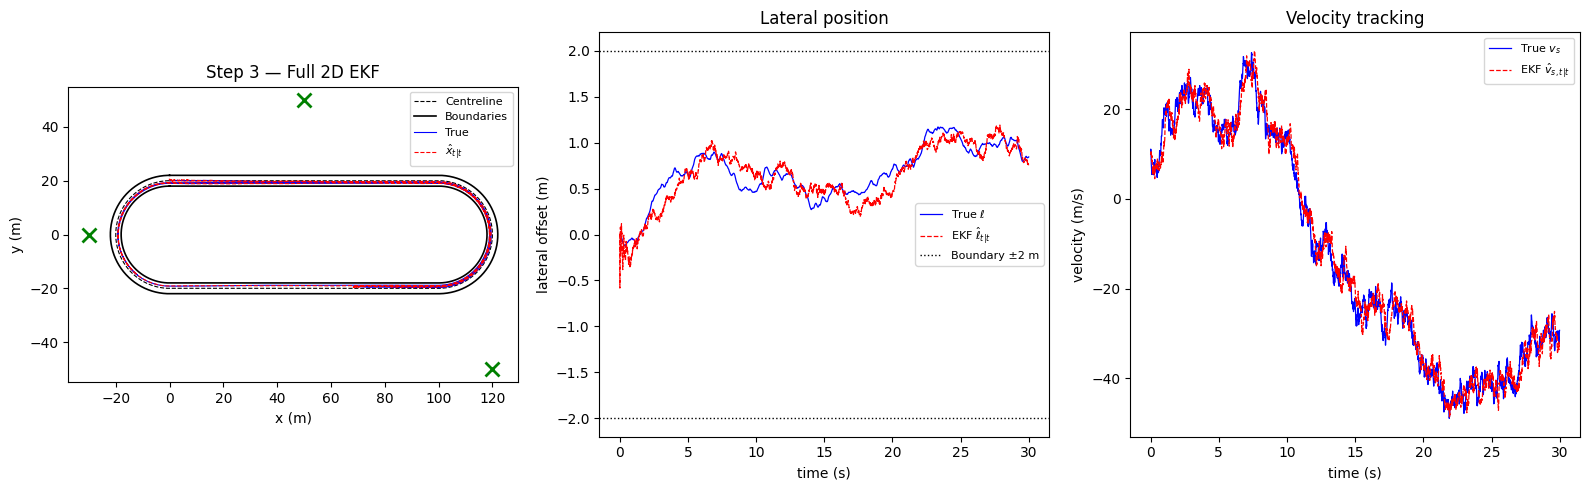

mean arc-length error  : 0.322 m
mean lateral error     : 0.118 m
lateral bounds OK      : True


In [3]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# Track geometry — from track_model.ipynb (member A: ChenhuiCui)
d   = 100.0
rho = 20.0
L   = 2*d + 2*np.pi*rho

def s_to_xy(s):
    s = s % L
    if s < d:
        return np.array([s, rho])
    elif s < d + np.pi*rho:
        theta = (s - d) / rho
        return np.array([d + rho*np.sin(theta), rho*np.cos(theta)])
    elif s < 2*d + np.pi*rho:
        return np.array([2*d + np.pi*rho - s, -rho])
    else:
        theta = (s - (2*d + np.pi*rho)) / rho
        return np.array([-rho*np.sin(theta), -rho*np.cos(theta)])

def s_to_normal(s):
    s = s % L
    if s < d:
        return np.array([0.0, -1.0])
    elif s < d + np.pi*rho:
        theta = (s - d) / rho
        return np.array([-np.sin(theta), -np.cos(theta)])
    elif s < 2*d + np.pi*rho:
        return np.array([0.0, 1.0])
    else:
        theta = (s - (2*d + np.pi*rho)) / rho
        return np.array([np.sin(theta), np.cos(theta)])

def sl_to_xy(s, ell):
    return s_to_xy(s) + ell * s_to_normal(s)

# system parameters
h   = 0.01   # 100 Hz
phi = 0.9    # lateral velocity damping (AR(1) model)

# x_t = [s, ell, v_s, v_ell]
A = np.array([
    [1, 0, h,   0  ],
    [0, 1, 0,   h  ],
    [0, 0, 1,   0  ],
    [0, 0, 0, phi  ]
])
G = np.array([[0,0],[0,0],[1,0],[0,1]])

Q_mat = np.diag([0.5, 0.02])
R     = 1.5**2

beacons = np.array([
    [ 50.0,  50.0],
    [120.0, -50.0],
    [-30.0,   0.0]
])
nb = len(beacons)

x_hat = np.array([[0.0], [0.0], [10.0], [0.0]])
P     = np.diag([100.0, 1.0, 25.0, 0.5])


def meas_fn(x, v):
    pos = sl_to_xy(float(x[0]), float(x[1]))
    return np.array([
        np.linalg.norm(pos - beacons[i]) + v[i]
        for i in range(nb)
    ])


def meas_jac(x):
    eps = 1e-5
    H   = np.zeros((nb, 4))
    h0  = meas_fn(x, np.zeros(nb))
    for j in range(2):
        x_eps    = x.copy()
        x_eps[j] += eps
        h1       = meas_fn(x_eps, np.zeros(nb))
        H[:, j]  = (h1.flatten() - h0.flatten()) / eps
    return H


def measurement_update(P, x_hat, y):
    H     = meas_jac(x_hat)
    S     = H @ P @ H.T + R * np.eye(nb)
    innov = y - meas_fn(x_hat, np.zeros(nb))
    x_hat = x_hat + P @ H.T @ np.linalg.solve(S, innov.reshape(-1, 1))
    P     = P - P @ H.T @ np.linalg.solve(S, H @ P)
    return P, x_hat


def time_update(P, x_hat):
    x_hat    = A @ x_hat
    x_hat[1] = np.clip(x_hat[1], -2.0, 2.0)
    P        = A @ P @ A.T + G @ Q_mat @ G.T
    return P, x_hat


# simulation
N      = 3000
x_true = np.array([[0.0], [0.0], [10.0], [0.0]])

true_log = np.zeros((N, 4))
est_log  = np.zeros((N - 1, 4))
true_log[0] = x_true.T

for t in range(N - 1):
    y             = meas_fn(x_true, np.random.normal(0, 1.5, nb))
    P, x_hat      = measurement_update(P, x_hat, y)
    est_log[t]    = x_hat.T
    P, x_hat      = time_update(P, x_hat)
    w             = np.array([[np.random.normal(0, np.sqrt(Q_mat[0,0]))],
                               [np.random.normal(0, np.sqrt(Q_mat[1,1]))]])
    x_true        = A @ x_true + G @ w
    x_true[1]     = np.clip(x_true[1], -2.0, 2.0)
    true_log[t+1] = x_true.T

# plots
s_vals   = np.linspace(0, L, 500)
track_xy = np.array([s_to_xy(s) for s in s_vals])
inner_xy = np.array([sl_to_xy(s, -2.0) for s in s_vals])
outer_xy = np.array([sl_to_xy(s,  2.0) for s in s_vals])
true_xy  = np.array([sl_to_xy(true_log[t,0], true_log[t,1]) for t in range(N)])
est_xy   = np.array([sl_to_xy(est_log[t,0],  est_log[t,1])  for t in range(N-1)])

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].plot(track_xy[:,0], track_xy[:,1], 'k--', lw=0.8, label='Centreline')
axes[0].plot(inner_xy[:,0], inner_xy[:,1], 'k-',  lw=1.2, label='Boundaries')
axes[0].plot(outer_xy[:,0], outer_xy[:,1], 'k-',  lw=1.2)
axes[0].plot(true_xy[:,0],  true_xy[:,1],  'b-',  lw=0.8, label='True')
axes[0].plot(est_xy[:,0],   est_xy[:,1],   'r--', lw=0.8, label=r'$\hat{x}_{t|t}$')
for b in beacons:
    axes[0].plot(b[0], b[1], 'gx', ms=10, mew=2)
axes[0].set_aspect('equal')
axes[0].set_xlabel('x (m)'); axes[0].set_ylabel('y (m)')
axes[0].legend(fontsize=8); axes[0].set_title('Step 3 — Full 2D EKF')

t_ax = np.arange(N) * h
axes[1].plot(t_ax,      true_log[:,1], 'b-',  lw=0.9, label=r'True $\ell$')
axes[1].plot(t_ax[:-1], est_log[:,1],  'r--', lw=0.9, label=r'EKF $\hat{\ell}_{t|t}$')
axes[1].axhline( 2.0, color='k', ls=':', lw=1.0, label='Boundary ±2 m')
axes[1].axhline(-2.0, color='k', ls=':', lw=1.0)
axes[1].set_xlabel('time (s)'); axes[1].set_ylabel('lateral offset (m)')
axes[1].legend(fontsize=8); axes[1].set_title('Lateral position')

axes[2].plot(t_ax,      true_log[:,2], 'b-',  lw=0.9, label=r'True $v_s$')
axes[2].plot(t_ax[:-1], est_log[:,2],  'r--', lw=0.9, label=r'EKF $\hat{v}_{s,t|t}$')
axes[2].set_xlabel('time (s)'); axes[2].set_ylabel('velocity (m/s)')
axes[2].legend(fontsize=8); axes[2].set_title('Velocity tracking')

plt.tight_layout()
plt.show()

print(f'mean arc-length error  : {np.mean(np.abs(true_log[:-1,0]-est_log[:,0])):.3f} m')
print(f'mean lateral error     : {np.mean(np.abs(true_log[:-1,1]-est_log[:,1])):.3f} m')
print(f'lateral bounds OK      : {np.all(np.abs(true_log[:,1]) <= 2.0)}')